## Setup
This version of the lab is designed to run locally on your machine. Please do not use JupyterHub to run this version as the lab requires more memory than allowed by JupyterHub.

## Introduction

In the game of [Wordle](https://www.nytimes.com/games/wordle/index.html), your goal is to deduce a 5-letter secret word that the game has generated using as few guesses as possible. After each guess, the game will tell you for each letter in your guess, whether the letter is

-  in the secret word and in the right spot (indicated by green),
-  in the secret word but in the wrong spot (indicated by yellow),
-  or not in the secret word (indicated by gray).

Take a look at the example game below where the secret word is "scald".

<div>
<img src="examples/ex-0.png" width="500"/>
</div>

Suppose we want to write a program that solves the problem as optimally as possible. In this lab, you will explore how to write a greedy algorithm using Information Theory. It's recommended that you try a game of Wordle to familiarize yourself with the rules.

In [1]:
# If modules have not been installed yet:

%pip install -r requirements.txt

# Restart kernel afterwards, if needed


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import hashlib
import matplotlib.pyplot as plt
from IPython.display import Image
from pathlib import Path
import pickle
from tqdm import tqdm
from functools import lru_cache
import random
import math
import os
import numpy as np

rng_seed = 0

## Modeling the Game

Here's some setup and simplifying assumptions about the game. First, we have obtained the list of 2315 words that can be chosen as the secret word. The secret word $X$ is modeled to be a random variable that has uniform distribution over these possible words. Second, your guess cannot be any arbitrary combination of 5 letters but needs to be from a list of 12972 valid guesses (which, of course, contains the 2315 possible secret words). Third, any revealed hints don't need to be used in subsequent guesses. With these, let's dive in!

Run the following cell to read in the list of possible secret words and the list of allowed guesses.

In [3]:
with open('data/possible_words.txt') as file:
    possible_words = [line.rstrip() for line in file]
with open('data/allowed_guesses.txt') as file:
    allowed_guesses = [line.rstrip() for line in file]

print('Number of possible_words:', len(possible_words))
print('Number of allowed_guesses:', len(allowed_guesses))

Number of possible_words: 2315
Number of allowed_guesses: 12972


Let's print out some of these words to take a look. `possible_words` consists of words used more frequently in the English language while `allowed_guesses` constains some words that we don't see in day-to-day life.

In [4]:
print('Some possible secret words:')
print(*random.sample(possible_words, 20), '\n')
print('Some allowed guesses:')
print(*random.sample(allowed_guesses, 20))

Some possible secret words:
curio break gruff blurt grape neigh dense moody board stash decor tidal psalm exact dwarf forum eject crate hater shame 

Some allowed guesses:
webby mhorr flype globs swoun farts slump hizen neals clast hiois rizas tavas nurdy porge paiks boral inker igged rumpy


<!-- BEGIN QUESTION -->

**Written Question 1:** The secret word is picked uniformly at random from 2315 possible words. What is the entropy of that distribution in unit of bits? And what does it mean about how many bits of information we need to gain to recover the secret word?

Feel free to use this space to draft your answer. When you finish, remember to paste your response and any relevant plots/figures **into the accompanying Gradescope assignment**.

log 2315, from hw

<!-- END QUESTION -->

## Implementing the Game Logic (Read Only)

We then implement the logic of the game by first computing the pattern that we will see for a given pair of guess and secret word. The function `compute_pattern` takes in a guess and a secret word, and returns an integer tuple of length 5 that represents the color pattern, where an entry of 2 represents green in the corresponding position, 1 represents yellow, and 0 represents gray.

There's an edge case that we will need to consider, which is when the guess and/or the secret word contains multiple of the same letter. The rule here is that green (match in the correct spot) always has the highest priority, yellow (match in the wrong spot) prioritizes letters in earlier positions of your guess, and each letter in the secret word can only correspond to one letter in the guess. Take a look at the example below.

- If the secret word is "abide" and the guess is "three", the pattern would be (0, 0, 0, 0, 2). Position 5 is an exact match so it has the highest priority to be green. Position 4 is indeed a match in the wrong spot, but since the "e" in "abide" is already taken, it cannot match to that same "e" again.

![title](examples/ex-1.png)

- If the secret word is "abide" and the guess is "drama", the pattern would be (1, 0, 1, 0, 0). Position 3 is a yellow match that has priority over the potential yellow match at position 5.

![title](examples/ex-2.png)

In [5]:
@lru_cache(maxsize=None)
def compute_pattern(guess, answer):
    # Returns a length 5 tuple
    
    pattern = [0, 0, 0, 0, 0]
    taken = [False, False, False, False, False]
    
    # Green pass
    for i in range(5):
        if guess[i] == answer[i]:
            # If it's an exact match, color it green, and mark it as taken
            # so that the yellow pass doesn't match to it again
            pattern[i] = 2
            taken[i] = True
    
    # Yellow pass
    for i in range(5):
        if pattern[i] == 2:
            # If a spot is already colored green, we skip it
            continue
        query = guess[i]
        for j in range(5):
            if query == answer[j] and taken[j] is False:
                # If there is a misplaced match that is not taken by the
                # green pass or a previous yellow pass, we color it yellow
                # and mark it as taken
                pattern[i] = 1
                taken[j] = True
                break
    
    return tuple(pattern)

Next, we compute the pattern between all pairs of potential guesses and potential answers, and tabulate the results for faster lookups in the future. In later parts of the lab, you should use `pattern_table[guess][answer]` instead of `compute_pattern(guess, answer)`.

*Note*: This version stores the table as a compact numpy matrix (`pattern_matrix`) instead of a giant nested dictionary. Each color pattern is encoded as an integer in base 3, and the matrix covers **all 12972 × 12972 pairs of allowed guesses** (~160MB) — not just the 2315 curated `possible_words`. This matters in practice: the NYT has used answers (e.g. "pshaw") that are valid guesses but are not in the original `possible_words` list, and with the full matrix the bot can fall back to the complete word list without losing any speed. Building the matrix is fully vectorized (well under a minute), and the result is cached in `checkpoint/pattern_matrix_full.npy`.

In [6]:
PATTERN_POWERS = 3 ** np.arange(4, -1, -1)  # [81, 27, 9, 3, 1]

def pattern_to_code(pattern):
    # length-5 tuple -> integer in [0, 243), e.g. (2, 1, 0, 0, 2) -> 191
    return int(np.dot(pattern, PATTERN_POWERS))

@lru_cache(maxsize=None)
def code_to_pattern(code):
    # integer in [0, 243) -> length-5 tuple
    digits = []
    for _ in range(5):
        digits.append(code % 3)
        code //= 3
    return tuple(reversed(digits))

def build_pattern_matrix(guesses, answers, chunk_size=512):
    # Vectorized equivalent of compute_pattern over all (guess, answer) pairs.
    # Returns a (len(guesses), len(answers)) uint8 matrix of base-3 pattern codes.
    g = np.array([[ord(c) - ord('a') for c in w] for w in guesses], dtype=np.uint8)
    a = np.array([[ord(c) - ord('a') for c in w] for w in answers], dtype=np.uint8)
    matrix = np.zeros((len(guesses), len(answers)), dtype=np.uint8)

    for start in tqdm(range(0, len(guesses), chunk_size)):
        gc = g[start:start + chunk_size]
        # eq[i, j, p, q]: does letter p of guess i equal letter q of answer j?
        eq = gc[:, None, :, None] == a[None, :, None, :]
        colors = np.zeros(eq.shape[:3], dtype=np.uint8)

        # Green pass: exact matches take the answer letter out of play
        for p in range(5):
            green = eq[:, :, p, p].copy()
            colors[:, :, p][green] = 2
            eq[:, :, :, p] &= ~green[:, :, None]

        # Yellow pass: earlier guess positions have priority, and each answer
        # letter can only be matched once
        for p in range(5):
            for q in range(5):
                match = eq[:, :, p, q] & (colors[:, :, p] == 0)
                colors[:, :, p][match] = 1
                eq[:, :, :, q] &= ~match[:, :, None]

        matrix[start:start + chunk_size] = colors @ PATTERN_POWERS

    return matrix

# The answer universe is ALL allowed guesses: the NYT has used answers (like
# 'pshaw') that are not in the curated possible_words list
pattern_matrix_path = os.path.join('checkpoint', 'pattern_matrix_full.npy')

if os.path.exists(pattern_matrix_path):
    pattern_matrix = np.load(pattern_matrix_path)
else:
    pattern_matrix = build_pattern_matrix(allowed_guesses, allowed_guesses)
    os.makedirs('checkpoint', exist_ok=True)
    np.save(pattern_matrix_path, pattern_matrix)

guess_index = {w: i for i, w in enumerate(allowed_guesses)}
answer_index = guess_index  # any allowed guess can be an answer

def get_pattern(guess, answer):
    # Fast table lookup; falls back to computing directly for words outside
    # the precomputed lists
    gi, ai = guess_index.get(guess), answer_index.get(answer)
    if gi is None or ai is None:
        return compute_pattern(guess, answer)
    return code_to_pattern(int(pattern_matrix[gi, ai]))

class _PatternTable:
    # Backwards-compatible pattern_table[guess][answer] lookups on top of the
    # numpy matrix, without materializing the huge dict
    class _Row:
        def __init__(self, guess):
            self.guess = guess
        def __getitem__(self, answer):
            return get_pattern(self.guess, answer)
    def __getitem__(self, guess):
        return self._Row(guess)

pattern_table = _PatternTable()

def filter_alphabet(alphabet, guess, color_pattern):
    # Keep only the words consistent with the observed pattern (vectorized)
    words = list(alphabet)
    if not words:
        return []
    gi = guess_index.get(guess)
    col_idx = [answer_index.get(w) for w in words]
    if gi is None or None in col_idx:
        return [w for w in words if compute_pattern(guess, w) == tuple(color_pattern)]
    codes = pattern_matrix[gi, np.array(col_idx, dtype=np.int64)]
    target = pattern_to_code(color_pattern)
    return [words[i] for i in np.nonzero(codes == target)[0]]

# Sanity check: the vectorized table must agree with compute_pattern
_rng = random.Random(0)
for _ in range(2000):
    _g, _a = _rng.choice(allowed_guesses), _rng.choice(allowed_guesses)
    assert pattern_table[_g][_a] == compute_pattern(_g, _a)
print('Pattern matrix ready:', pattern_matrix.shape, '- matches compute_pattern on 2000 random pairs')

Pattern matrix ready: (12972, 12972) - matches compute_pattern on 2000 random pairs


## Guess Strategy

We use the term "alphabet of a random variable" to mean the set of potential values it could take on with positive probability (not to be confused with the English alphabet). For example, the alphabet of $X$ is the set of 2315 possible secret words.

Fix a time index $t$. Let $X_t = X|Y_1, \ldots, Y_{t-1}$ where $Y_i$ is the pattern we observe after our $i$-th guess, which we assume has already happened. Then, we can see that $X_t$ also has a uniform distribution over its alphabet because the color pattens we observe only tell us which secret words are possible and which are not, but do not change the relative probabilities assigned to the possible secret words. In other words, we can think of each guess as "narrowing down" the alphabet of $X$.

Let $Y_{t,k}$ be the resulting pattern for guessing the word $k$ at timestep $t$. Both $X_t$ and $Y_{t,k}$ are random variables. Note that the index $k$ here is a word we guess. We want to minimize the conditional entropy $H(X_t|Y_{t,k})$ over $k \in$ `allowed_guesses` since it's the "leftover uncertainty" about $X_t$ after observing the color pattern for $k$. Namely, if $Y_t=Y_{t,k}$ (meaning that we guess word $k$), then $H(X_t|Y_{t,k})=\log_2 |\text{alphabet of $X_{t+1}$}|$ since $X_{t+1}$ is still uniform over its alphabet.

Recall that $$H(X_t)=I(X_t;Y_{t,k})+H(X_t|Y_{t,k}).$$

Since $H(X_t)$ is a constant given a particular observation of $Y_1, \ldots, Y_{t-1} = (y_1, \ldots, y_{t-1})$, minimizing $H(X_t|Y_{t,k})$ is equivalent to maximizing $I(X_t;Y_{t,k})$.

But what is $I(X_t;Y_{t,k})$? The mutual information is the amount of information in $X_t$ gained through observing $Y_{t,k}$, which equals the amount of information in $Y_{t,k}$ gained through observing $X_t$. However, if we know $X_t$ (which means we peek at the answer), then $Y_{t,k}|X_t$ is deterministic! Knowing $X_t$ would reduce the uncertainty in $Y_{t,k}$ from $H(Y_{t,k})$ to $0$, which means that

$$I(X_t;Y_{t,k})=H(Y_{t,k})-H(Y_{t,k}|X_t)=H(Y_{t,k})-0=H(Y_{t,k}).$$

The conclusion is that we reformulate the problem of minimizing $H(X_t|Y_{t,k})$ into maximizing $I(X_t;Y_{t,k})$ then into maximizing $H(Y_{t,k})$. Please make sure you fully understand our steps above!

**Task 1**: Let's start by implementating `divide_alphabet`, which takes in a guess and the current alphabet. The function would split the alphabet into smaller subgroups. Namely, it returns a dictionary that maps from the set of possible color patterns to the set of secret words such that `pattern_table[guess][secret_word]` is that color pattern. For example, if `guess` is "shake" and `alphabet` is {shape, shake, shame}, then the function should return the mapping (2,2,2,2,2)$\to${shake}, (2,2,2,0,2)$\to${shape, shame}.

In [7]:
def divide_alphabet(guess, alphabet):
    pattern_to_subgroup = {}

    for word in alphabet:
        pattern = pattern_table[guess][word]
        pattern_to_subgroup.setdefault(pattern, []).append(word)

    return pattern_to_subgroup

Then, since $X$ is uniform over its alphabet, the probability that we observe each pattern is proportional to the number of words in that subgroup. 

**Task 2:** In the following cell, implement `prob_dist`, which takes in the output of the above function and returns the probability distribution over the set of possible patterns. For the same example above, this function would take in the mapping (2,2,2,2,2)$\to${shake}, (2,2,2,0,2)$\to${shape, shame} and return $\left[\frac{1}{3}, \frac{2}{3}\right]$ This is the distribution of $Y_{t,k}$.

In [8]:
def prob_dist(pattern_groups):
    # returns a probability distribution in the form of a list
    # for example, if the probability distribution is
    # P(pattern_1) = 0.2, P(pattern_2) = 0.3, P(pattern_3) = 0.5,
    # this function should return [0.2, 0.3, 0.5]. Order doesn't matter
    dist = []
    total = 0
    for i in pattern_groups.values():
        total += len(i)
        dist.append(len(i))
    for i in range(0,len(dist)):
        dist[i] /= total
    return dist

**Task 3:** In the cell below, implement the function `entropy`, which takes in a probability distribution (in a list format, like the output of the previous function) and outputs its entropy. You may assume that the distribution has no entry of $0$ and is a valid distribution. From this we can find $H(Y_k)$, which is the quantity we seek to maximize.

In [9]:
def entropy(dist):
    return sum([-x * math.log2(x) for x in dist])

**Task 4**: Now we're into business! We've specified how to quantitatively compare quality of guesses, and let's now implement `find_best_guess`, which takes in the alphabet of $X_t$ and returns the best guess to make. Recall that the best guess is a guess $k\in$ `allowed_guesses` that maximizes $H(Y_{t,k})$.

In [10]:
def guess_entropies(alphabet, guesses):
    # Expected information gain H(Y_{t,k}) in bits for every guess at once.
    # One gather + one bincount over the pattern matrix replaces millions of
    # Python-level compute_pattern calls.
    words = list(alphabet)
    row_idx = [guess_index.get(g) for g in guesses]
    col_idx = [answer_index.get(w) for w in words]
    if None in row_idx or None in col_idx:
        # fall back to the direct computation for out-of-list words
        return np.array([entropy(prob_dist(divide_alphabet(g, words))) for g in guesses])
    sub = pattern_matrix[np.ix_(np.array(row_idx), np.array(col_idx))].astype(np.int64)
    sub += np.arange(len(row_idx))[:, None] * 243  # offset so each guess gets its own bins
    counts = np.bincount(sub.ravel(), minlength=len(row_idx) * 243).reshape(len(row_idx), 243)
    probs = counts / len(words)
    plogp = np.zeros_like(probs)
    nonzero = probs > 0
    plogp[nonzero] = probs[nonzero] * np.log2(probs[nonzero])
    return -plogp.sum(axis=1)

def find_best_guess(alphabet, allowed_guesses, use_tqdm=False):
    # use_tqdm is kept for compatibility; the vectorized version finishes in
    # a fraction of a second, so there is no progress to watch
    guesses = list(allowed_guesses)
    if len(guesses) == 0 or len(alphabet) == 0:
        return None
    entropies = guess_entropies(alphabet, guesses)
    alpha_set = set(alphabet)
    in_alpha = np.array([g in alpha_set for g in guesses])
    # among guesses tied for the highest entropy, prefer one that could be
    # the answer itself - it might win on the spot
    best = int(np.lexsort((in_alpha, entropies))[-1])
    if entropies[best] <= 0:
        return None
    return guesses[best]

In [11]:
def find_best_n_guesses(alphabet, allowed_guesses, n=5, use_tqdm=False):
    guesses = list(allowed_guesses)
    entropies = guess_entropies(alphabet, guesses)
    alpha_set = set(alphabet)
    in_alpha = np.array([g in alpha_set for g in guesses], dtype=np.int8)
    # sort by entropy (descending); break exact ties in favor of words that
    # could be the answer themselves
    order = np.lexsort((-in_alpha, -entropies))[:n]
    return [(guesses[i], float(entropies[i])) for i in order]

## Best Wordle Opener

Here is the question that Wordle lovers are looking for: What is the best opening guess under our scheme? (**Important Note:** this is the best opener given our assumptions that the secret word is picked *uniformly at random* over the 2315 possible secret words, and we are using a greedy algorithm to get the most information out of each guess. This is not guaranteed to be the truly optimal guess.)

In [12]:
best_opener = find_best_guess(possible_words, allowed_guesses, use_tqdm=True)

In [13]:
print('The best Wordle opener is:', best_opener)

The best Wordle opener is: soare


The correct answer to the previous output is "soare", which is an obsolete form of sore (“A young hawk”) by Collins dictionary. Let's plot out the distribution of patterns we observe if we open with "soare", then compare it with if we opened with "speed" — a mediocre opener, and "qajaq" (which is an alternative spelling of kayak) — the worst opener. Since there's no natural ordering to pattern, we will instead order the patterns on the x-axis by decreasing probability.

Expected information gain: 5.89 bits out of 11.18 bits


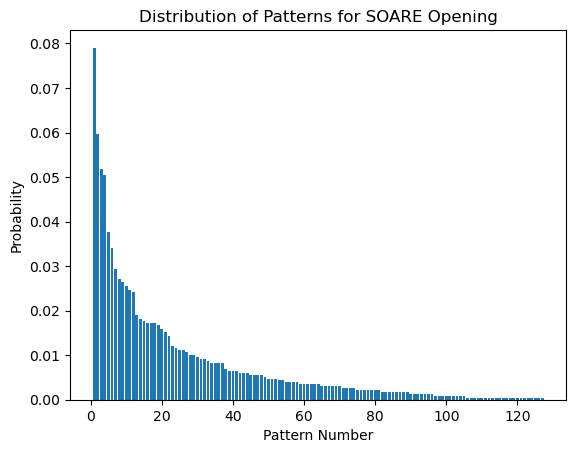

In [14]:
distribution = prob_dist(divide_alphabet('soare', possible_words))
print(f'Expected information gain: {round(entropy(distribution),2)} bits out of 11.18 bits')
distribution.sort(reverse=True)
patterns = list(range(1, len(distribution) + 1))
plt.bar(patterns, distribution)
plt.title('Distribution of Patterns for SOARE Opening')
plt.xlabel('Pattern Number')
plt.ylabel('Probability')
plt.show()

Expected information gain: 4.37 bits out of 11.18 bits


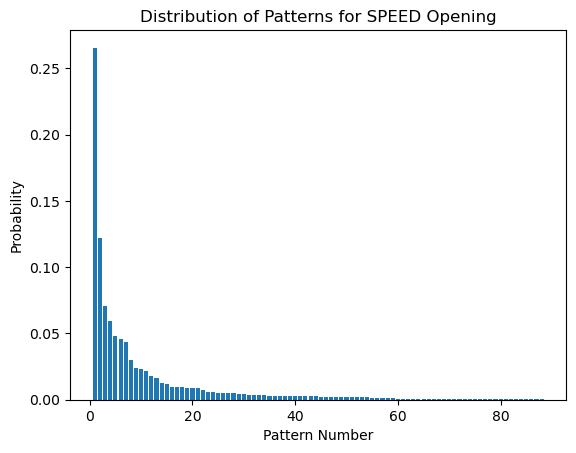

In [15]:
distribution = prob_dist(divide_alphabet('speed', possible_words))
print(f'Expected information gain: {round(entropy(distribution),2)} bits out of 11.18 bits')
distribution.sort(reverse=True)
patterns = list(range(1, len(distribution) + 1))
plt.bar(patterns, distribution)
plt.title('Distribution of Patterns for SPEED Opening')
plt.xlabel('Pattern Number')
plt.ylabel('Probability')
plt.show()

Expected information gain: 1.89 bits out of 11.18 bits


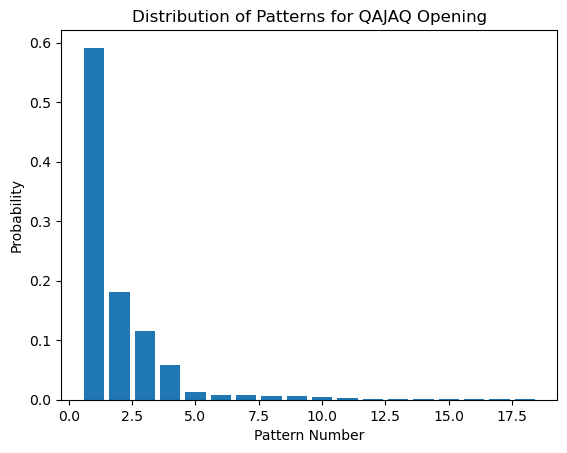

In [16]:
distribution = prob_dist(divide_alphabet('qajaq', possible_words))
print(f'Expected information gain: {round(entropy(distribution),2)} bits out of 11.18 bits')
distribution.sort(reverse=True)
patterns = list(range(1, len(distribution) + 1))
plt.bar(patterns, distribution)
plt.title('Distribution of Patterns for QAJAQ Opening')
plt.xlabel('Pattern Number')
plt.ylabel('Probability')
plt.show()

The "qajaq" opener is so bad that only a few patterns have a positive probability of appearing, which has a very low entropy. Note that the horizontal axis of the last graph is on a different scale from the previous graphs.

<!-- BEGIN QUESTION -->

**Written Question 2:** From how the graphs look, which one has a higher entropy and why? And why does it suggest "soare" is a better opener than "speed"?

Feel free to use this space to draft your answer. When you finish, remember to paste your response and any relevant plots/figures **into the accompanying Gradescope assignment**.

<!-- END QUESTION -->

## Some Useful Optimizations (Read Only)

This part has no implementation that you need to do, but it's highly recommended that you read through this section.

The calculation to find "soare" took a while to run, didn't it? You may realize that the opening guess is always made without any observed pattern, so we don't need to calculate it every time, but can instead save the result that if it's our first guess, we would always return "soare".

Another thing is that now our guesses always come from the huge list of allowed guesses. Suppose that we have now narrowed the alphabet of $X_t$ down to 2 words, "price" and "pride". Guessing a word that isn't in the alphabet, such as "camel", will certainly tell us which one is the correct answer (since it tells us whether there is a "c" in the answer), but we will still need to use a guess to report the correct answer, for a total of 2 additional guesses. However, if we guess a word in the alphabet, not only will it tell us which one of "price" and "pride" is the answer, but also we have a $\frac{1}{2}$ probability to hit it right there so we don't need another guess. Therefore, when the remaining alphabet is small ($\leq 3$), we can instead limit our guesses to within the alphabet.

The following function implements these optimization ideas. Take a look at it to see what's going on.

In [12]:
def find_best_guess_optimized(alphabet):
    if len(alphabet) == 2315:
        # if it's the opening guess, we directly output 'soare'
        return 'soare'
    elif len(alphabet) == 1:
        # if we are certain what the secret word is, directly guess it
        return alphabet[0]
    elif len(alphabet) <= 3:
        # if the alphabet is small, limit our guess to within the alphabet
        return find_best_guess(alphabet, alphabet)
    else:
        # otherwise, we apply no optimization
        return find_best_guess(alphabet, allowed_guesses)

## Performance Test

Let's now sample some secret words and watch our algorithm find the secret word in action! 

**Task 5:** Implement the function `play_wordle`, which takes in the true secret word and simulates a Wordle game using our algorithm above.

In [13]:
def create_wordle_game(true_answer):
    def wordle_game(guess):
        # takes in a guess and outputs the pattern
        # return pattern_table[guess][true_answer]
        return compute_pattern(guess, true_answer)
    
    return wordle_game

In [14]:
def play_wordle(wordle_game, print_guesses=False):
    alphabet = possible_words
    num_guesses = 0
    while True:
        num_guesses += 1
        guess = find_best_guess_optimized(alphabet)
        color_pattern = wordle_game(guess)
        if print_guesses:
            print(f'Guess {num_guesses}: {guess}  |  Pattern: {color_pattern}')
        if color_pattern == (2, 2, 2, 2, 2):
            # correct answer!
            break
        # narrow the alphabet down to the words consistent with the pattern
        alphabet = filter_alphabet(alphabet, guess, color_pattern)

    return num_guesses

In [20]:
for _ in range(10):
    true_answer = random.choice(possible_words)
    print('Secret word:', true_answer)
    wordle_game = create_wordle_game(true_answer)
    play_wordle(wordle_game, print_guesses=True)
    print()

Secret word: alarm
Guess 1: soare  |  Pattern: (0, 0, 2, 2, 0)


Guess 2: dhuti  |  Pattern: (0, 0, 0, 0, 0)
Guess 3: alarm  |  Pattern: (2, 2, 2, 2, 2)

Secret word: medal
Guess 1: soare  |  Pattern: (0, 0, 1, 0, 1)
Guess 2: canal  |  Pattern: (0, 0, 0, 2, 2)
Guess 3: tempi  |  Pattern: (0, 2, 1, 0, 0)
Guess 4: medal  |  Pattern: (2, 2, 2, 2, 2)

Secret word: grace
Guess 1: soare  |  Pattern: (0, 0, 2, 1, 2)


Guess 2: ditch  |  Pattern: (0, 0, 0, 2, 0)
Guess 3: grace  |  Pattern: (2, 2, 2, 2, 2)

Secret word: annex
Guess 1: soare  |  Pattern: (0, 0, 1, 0, 1)


Guess 2: canal  |  Pattern: (0, 1, 2, 0, 0)
Guess 3: annex  |  Pattern: (2, 2, 2, 2, 2)

Secret word: roast
Guess 1: soare  |  Pattern: (1, 2, 2, 1, 0)
Guess 2: roast  |  Pattern: (2, 2, 2, 2, 2)

Secret word: viola
Guess 1: soare  |  Pattern: (0, 1, 1, 0, 0)
Guess 2: cloot  |  Pattern: (0, 1, 2, 0, 0)
Guess 3: viola  |  Pattern: (2, 2, 2, 2, 2)

Secret word: scant
Guess 1: soare  |  Pattern: (2, 0, 2, 0, 0)


Guess 2: thilk  |  Pattern: (1, 0, 0, 0, 0)
Guess 3: upend  |  Pattern: (0, 0, 0, 2, 0)
Guess 4: scant  |  Pattern: (2, 2, 2, 2, 2)

Secret word: feast
Guess 1: soare  |  Pattern: (1, 0, 2, 0, 1)


Guess 2: lofty  |  Pattern: (0, 0, 1, 1, 0)
Guess 3: feast  |  Pattern: (2, 2, 2, 2, 2)

Secret word: clown
Guess 1: soare  |  Pattern: (0, 1, 0, 0, 0)
Guess 2: clint  |  Pattern: (2, 2, 0, 1, 0)
Guess 3: clown  |  Pattern: (2, 2, 2, 2, 2)

Secret word: chess
Guess 1: soare  |  Pattern: (1, 0, 0, 0, 1)
Guess 2: uneth  |  Pattern: (0, 0, 2, 0, 1)
Guess 3: chess  |  Pattern: (2, 2, 2, 2, 2)



Let's take a look at the distribution of the number of guesses needed by sampling 300 secret words. 

This cell may take a few minutes to run. If it takes way too long to run, you can instead sample fewer secret words.

In [21]:
num_guesses = []
num_samples = 300
for true_answer in tqdm(random.sample(possible_words, num_samples)):
    num_guesses.append(play_wordle(create_wordle_game(true_answer)))


  0%|          | 0/300 [00:00<?, ?it/s]


  0%|          | 1/300 [00:00<00:36,  8.19it/s]


  1%|          | 3/300 [00:00<00:30,  9.79it/s]


  2%|▏         | 6/300 [00:00<00:24, 12.21it/s]


  3%|▎         | 8/300 [00:00<00:21, 13.80it/s]

...


 97%|█████████▋| 292/300 [00:20<00:00, 13.23it/s]


 98%|█████████▊| 294/300 [00:21<00:00, 10.96it/s]


 99%|█████████▉| 297/300 [00:21<00:00, 13.78it/s]


100%|█████████▉| 299/300 [00:21<00:00, 13.21it/s]


100%|██████████| 300/300 [00:21<00:00, 13.88it/s]

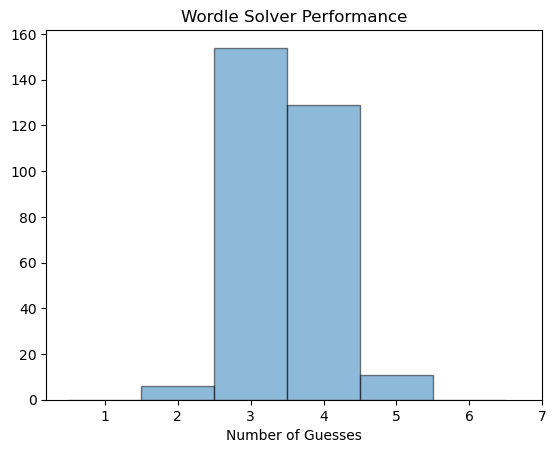

In [22]:
bins = list(range(1, 8))
plt.hist(num_guesses, bins, alpha=0.5, edgecolor='black', align='left')
plt.xlabel('Number of Guesses')
plt.xticks(list(range(1, 8)))
plt.title('Wordle Solver Performance')
plt.show()

If your implementation is correct, your Wordle solver takes fewer guesses on average than American players on average.

In [23]:
print(f'Average number of Wordle guesses using entropy: {round(sum(num_guesses)/len(num_guesses), 3)}')
print('Average number of Wordle guesses for Americans: 3.92')

Average number of Wordle guesses using entropy: 3.483
Average number of Wordle guesses for Americans: 3.92


In [24]:
#print out the best 20 guesses for the initial guess
best_guesses = find_best_n_guesses(possible_words, allowed_guesses, n=20, use_tqdm=True)
print('Best 20 guesses for the initial guess:')
for guess, info_gain in best_guesses:
    print(f'{guess}: {round(info_gain, 2)} bits of expected information gain')

Best 20 guesses for the initial guess:
soare: 5.89 bits of expected information gain
roate: 5.88 bits of expected information gain
raise: 5.88 bits of expected information gain
raile: 5.87 bits of expected information gain
reast: 5.87 bits of expected information gain
slate: 5.86 bits of expected information gain
crate: 5.83 bits of expected information gain
salet: 5.83 bits of expected information gain
irate: 5.83 bits of expected information gain
trace: 5.83 bits of expected information gain
arise: 5.82 bits of expected information gain
orate: 5.82 bits of expected information gain
stare: 5.81 bits of expected information gain
carte: 5.79 bits of expected information gain
raine: 5.79 bits of expected information gain
caret: 5.78 bits of expected information gain
ariel: 5.78 bits of expected information gain
taler: 5.77 bits of expected information gain
carle: 5.77 bits of expected information gain
slane: 5.77 bits of expected information gain


## Wordle Bot! (Optional)

For the final part of the lab, let's use what we've built so far and transform it into a Wordle bot! **Implement the following class `WordleBot`** that interactively outputs its suggested guess, and receives inputs that consist of your actual guess and the pattern displayed. Feel free to modify the code below to tailor the bot to your liking, such as outputting more than one suggested word, outputting the word along with its mutual information with the secret word, or giving it a better user interface in your personal project!

In [15]:
class WordleBot:
    # The bot tracks TWO candidate sets:
    #   - self.candidates: consistent words from possible_words (the curated
    #     answer list - by far the most likely answers)
    #   - self.extended: consistent words from the full allowed_guesses list.
    #     The NYT sometimes picks answers outside the curated list (e.g.
    #     'pshaw'), so when no curated word fits anymore, the bot falls back
    #     to this set instead of giving up.
    def __init__(self, num_suggestions=10, max_listed=50):
        # num_suggestions: how many top guesses to rank each turn
        # max_listed: list every remaining possible word automatically when
        #             there are at most this many (bot.show_possible() prints
        #             the full list at any time)
        self.num_suggestions = num_suggestions
        self.max_listed = max_listed
        self.restart()

    @property
    def alphabet(self):
        # what the secret word could still be: curated words if any fit,
        # otherwise every allowed word that fits
        return self.candidates if self.candidates else self.extended

    def show_possible(self):
        # print every word the secret could still be
        alphabet = self.alphabet
        print(f'{len(alphabet)} possible word(s) remaining:')
        for start in range(0, len(alphabet), 12):
            print('  ' + ' '.join(alphabet[start:start + 12]))

    def suggest(self):
        # list the remaining possible words, rank the best next guesses,
        # and return the top suggestion
        alphabet = self.alphabet
        if len(alphabet) == 0:
            print('No valid words remain - a pattern was probably entered '
                  'incorrectly. Call restart() to reset.')
            return None
        if not self.candidates:
            print("None of the common answer words fit anymore - the secret "
                  "word must be an uncommon one. Searching the full word list.")
        if len(alphabet) == 1:
            print('The secret word is:', alphabet[0])
            return alphabet[0]

        if len(alphabet) <= self.max_listed:
            self.show_possible()
        else:
            print(f'{len(alphabet)} possible words remaining '
                  '(call bot.show_possible() to list them all)')
        long_shots = len(self.extended) - len(self.candidates)
        if self.candidates and long_shots:
            print(f'({long_shots} uncommon valid words also fit - see bot.extended)')

        possible = set(alphabet)
        if len(alphabet) <= 3:
            # with so few words left, guessing inside the alphabet dominates
            ranked = find_best_n_guesses(alphabet, alphabet,
                                         n=self.num_suggestions)
        else:
            ranked = find_best_n_guesses(alphabet, allowed_guesses,
                                         n=self.num_suggestions)
        print('Top suggested guesses:')
        for word, bits in ranked:
            tag = '  <- possible answer' if word in possible else ''
            print(f'  {word}: {bits:.3f} bits{tag}')

        if len(alphabet) > 3 and not any(w in possible for w, _ in ranked):
            # make sure actual candidate answers are always proposed too
            in_alphabet = find_best_n_guesses(alphabet, alphabet,
                                              n=min(self.num_suggestions, len(alphabet)))
            print('Best guesses among possible answers:')
            for word, bits in in_alphabet:
                print(f'  {word}: {bits:.3f} bits')
        return ranked[0][0]

    def observe(self, word, pattern):
        # after a guess, feed the pattern to the bot to update both candidate
        # sets; the bot then suggests (and returns) the next word to guess
        assert len(word) == len(pattern) == 5
        pattern = tuple(pattern)
        self.candidates = filter_alphabet(self.candidates, word, pattern)
        self.extended = filter_alphabet(self.extended, word, pattern)
        return self.suggest()

    def restart(self):
        # re-initialize the bot for a new game
        self.candidates = list(possible_words)
        self.extended = list(allowed_guesses)

In [16]:
bot = WordleBot()
bot.suggest()

2315 possible words remaining (call bot.show_possible() to list them all)
(10657 uncommon valid words also fit - see bot.extended)
Top suggested guesses:
  soare: 5.886 bits
  roate: 5.883 bits
  raise: 5.878 bits  <- possible answer
  raile: 5.866 bits
  reast: 5.865 bits
  slate: 5.856 bits  <- possible answer
  crate: 5.835 bits  <- possible answer
  salet: 5.835 bits
  irate: 5.831 bits  <- possible answer
  trace: 5.831 bits  <- possible answer


'soare'

In [17]:
# a real game where the answer was 'pshaw' - which is NOT in possible_words!
bot.observe('soare', (1,0,1,0,0))

23 possible word(s) remaining:
  abyss amiss angst assay basal basic basil basin basis daisy gassy hasty
  nasal nasty palsy pansy pasta pasty patsy tasty usual vista waist
(578 uncommon valid words also fit - see bot.extended)
Top suggested guesses:
  linty: 3.936 bits
  unity: 3.903 bits
  patin: 3.849 bits
  tiyns: 3.849 bits
  lysis: 3.828 bits
  panty: 3.828 bits
  nyssa: 3.816 bits
  pissy: 3.816 bits
  tiyin: 3.816 bits
  tying: 3.816 bits
Best guesses among possible answers:
  nasty: 3.795 bits
  pansy: 3.741 bits
  palsy: 3.642 bits
  nasal: 3.556 bits
  basin: 3.551 bits
  basil: 3.469 bits
  pasty: 3.469 bits
  patsy: 3.469 bits
  pasta: 3.431 bits
  assay: 3.393 bits


'linty'

In [18]:
bot.observe('linty', (0,0,0,0,0))

None of the common answer words fit anymore - the secret word must be an uncommon one. Searching the full word list.
152 possible words remaining (call bot.show_possible() to list them all)
Top suggested guesses:
  chump: 4.411 bits
  bumph: 4.338 bits
  mucks: 4.293 bits
  pucks: 4.272 bits
  mahua: 4.259 bits
  hakam: 4.214 bits
  pucka: 4.196 bits
  mapau: 4.195 bits
  whump: 4.184 bits
  kacha: 4.174 bits
Best guesses among possible answers:
  pukas: 4.023 bits
  pumas: 4.004 bits
  humas: 3.965 bits
  kapus: 3.940 bits
  cauks: 3.920 bits
  kasha: 3.917 bits
  paska: 3.912 bits
  hakus: 3.854 bits
  caups: 3.850 bits
  camus: 3.842 bits


'chump'

In [19]:
bot.observe('chump', (0,1,0,0,1))

None of the common answer words fit anymore - the secret word must be an uncommon one. Searching the full word list.
4 possible word(s) remaining:
  hasps kaphs pasha pshaw
Top suggested guesses:
  hasps: 2.000 bits  <- possible answer
  kaphs: 2.000 bits  <- possible answer
  pasha: 2.000 bits  <- possible answer
  akkas: 2.000 bits
  alaps: 2.000 bits
  amahs: 2.000 bits
  amass: 2.000 bits
  ankhs: 2.000 bits
  ansae: 2.000 bits
  apeak: 2.000 bits


'hasps'

In [21]:
bot.observe('hasps', (1,1,1,1,0))

None of the common answer words fit anymore - the secret word must be an uncommon one. Searching the full word list.
The secret word is: pshaw


'pshaw'